# AMAZON SALES AND REVIEW ANALYSIS

# Exploratory Data Analysis and Visualizations
_________________________________________________

## objectives

 The main objective of Exploratory Data Analysis (EDA) and Visualization is to understand the Dataset, identify patterns,detect anomalies, and extract meaningful insights before building models or making business decisions.

# STEP 3 : Exploratory Data Analysis 

# APPLIED ANALYSIS

* Univariate
* Bivariate
* Multivariate
* groupby
* pivot_table
* Correlation
______________

* descriptive statistics - df.describe()

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('amazon_cleaned.csv')

In [3]:
numeric_cols = ['discounted_price','actual_price','discount_percentage',
               'rating','rating_count','savings_amount']
df[numeric_cols].describe().round(2)

,discounted_price,actual_price,discount_percentage,rating,rating_count,savings_amount
count,1465.00,1465.00,1465.00,1465.00,1465.00,1465.00
mean,3125.31,5444.99,47.69,4.10,18270.56,2319.68
std,6944.30,10874.83,21.64,0.29,42730.00,4604.47
min,39.00,39.00,0.00,2.00,0.00,0.00
25%,325.00,800.00,32.00,4.00,1173.00,371.00
50%,799.00,1650.00,50.00,4.10,5178.00,800.00
75%,1999.00,4295.00,63.00,4.30,17325.00,1953.00
max,77990.00,139900.00,94.00,5.00,426973.00,61910.00


* univariate analysis -value_counts & frequency

In [4]:
print(df['main_category'].value_counts())
print(df['rating_band'].value_counts())
print(df['discount_tire'].value_counts())
print(df['price_category'].value_counts())

main_category
Electronics              526
Computers&Accessories    453
Home&Kitchen             448
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64
rating_band
Good         1007
Average       312
Excellent     104
poor           42
Name: count, dtype: int64
discount_tire
Medium(40%-69%)    728
Low (<40%)         490
High (>=70%)       247
Name: count, dtype: int64
price_category
Mid-range (300-999)    472
Premium (1000-2999)    370
Budget (<=299)         356
Luxury (3000+)         267
Name: count, dtype: int64


* bivariate analysis-groupby aggregations

In [5]:
cat_agg =df.groupby('main_category').agg(
    count         = ('product_id',             'count'),
    avg_rating    = ('rating',                 'mean'),
    avd_discount  =  ('discount_percentage',    'mean'),
    avd_price     =  ('discounted_price',        'mean'),
    avg_savings   =  ('savings_amount',           'mean')
).round(2).sort_values('avg_rating',ascending=False)




In [6]:
df.groupby('price_category')['rating'].mean().round(3)
df.groupby('discount_tire')['rating'].mean().round(3)


discount_tire
High (>=70%)       4.032
Low (<40%)         4.146
Medium(40%-69%)    4.085
Name: rating, dtype: float64

* pivot table - pd.pivot_table()

In [7]:
piv1 =pd.pivot_table(df,values='product_id',
                     index='main_category',columns='price_category',
                     aggfunc='count',fill_value=0)
piv2=pd.pivot_table(df,values='discount_percentage',
                    index='rating_band',columns='price_category',
                    aggfunc='mean').round(1)

* correlation analysis - df.corr()

In [8]:
corr_cols =['discounted_price','actual_price','discount_percentage',
           'rating','rating_count','savings_amount']
df[corr_cols].corr().round(3)

,discounted_price,actual_price,discount_percentage,rating,rating_count,savings_amount
discounted_price,1.000,0.962,-0.242,0.120,-0.027,0.764
actual_price,0.962,1.000,-0.118,0.122,-0.036,0.911
discount_percentage,-0.242,-0.118,1.000,-0.155,0.011,0.087
rating,0.120,0.122,-0.155,1.000,0.102,0.106
rating_count,-0.027,-0.036,0.011,0.102,1.000,-0.044
savings_amount,0.764,0.911,0.087,0.106,-0.044,1.000


# STEP 4: visualizations

figure 1 - Univariate Distributions

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np


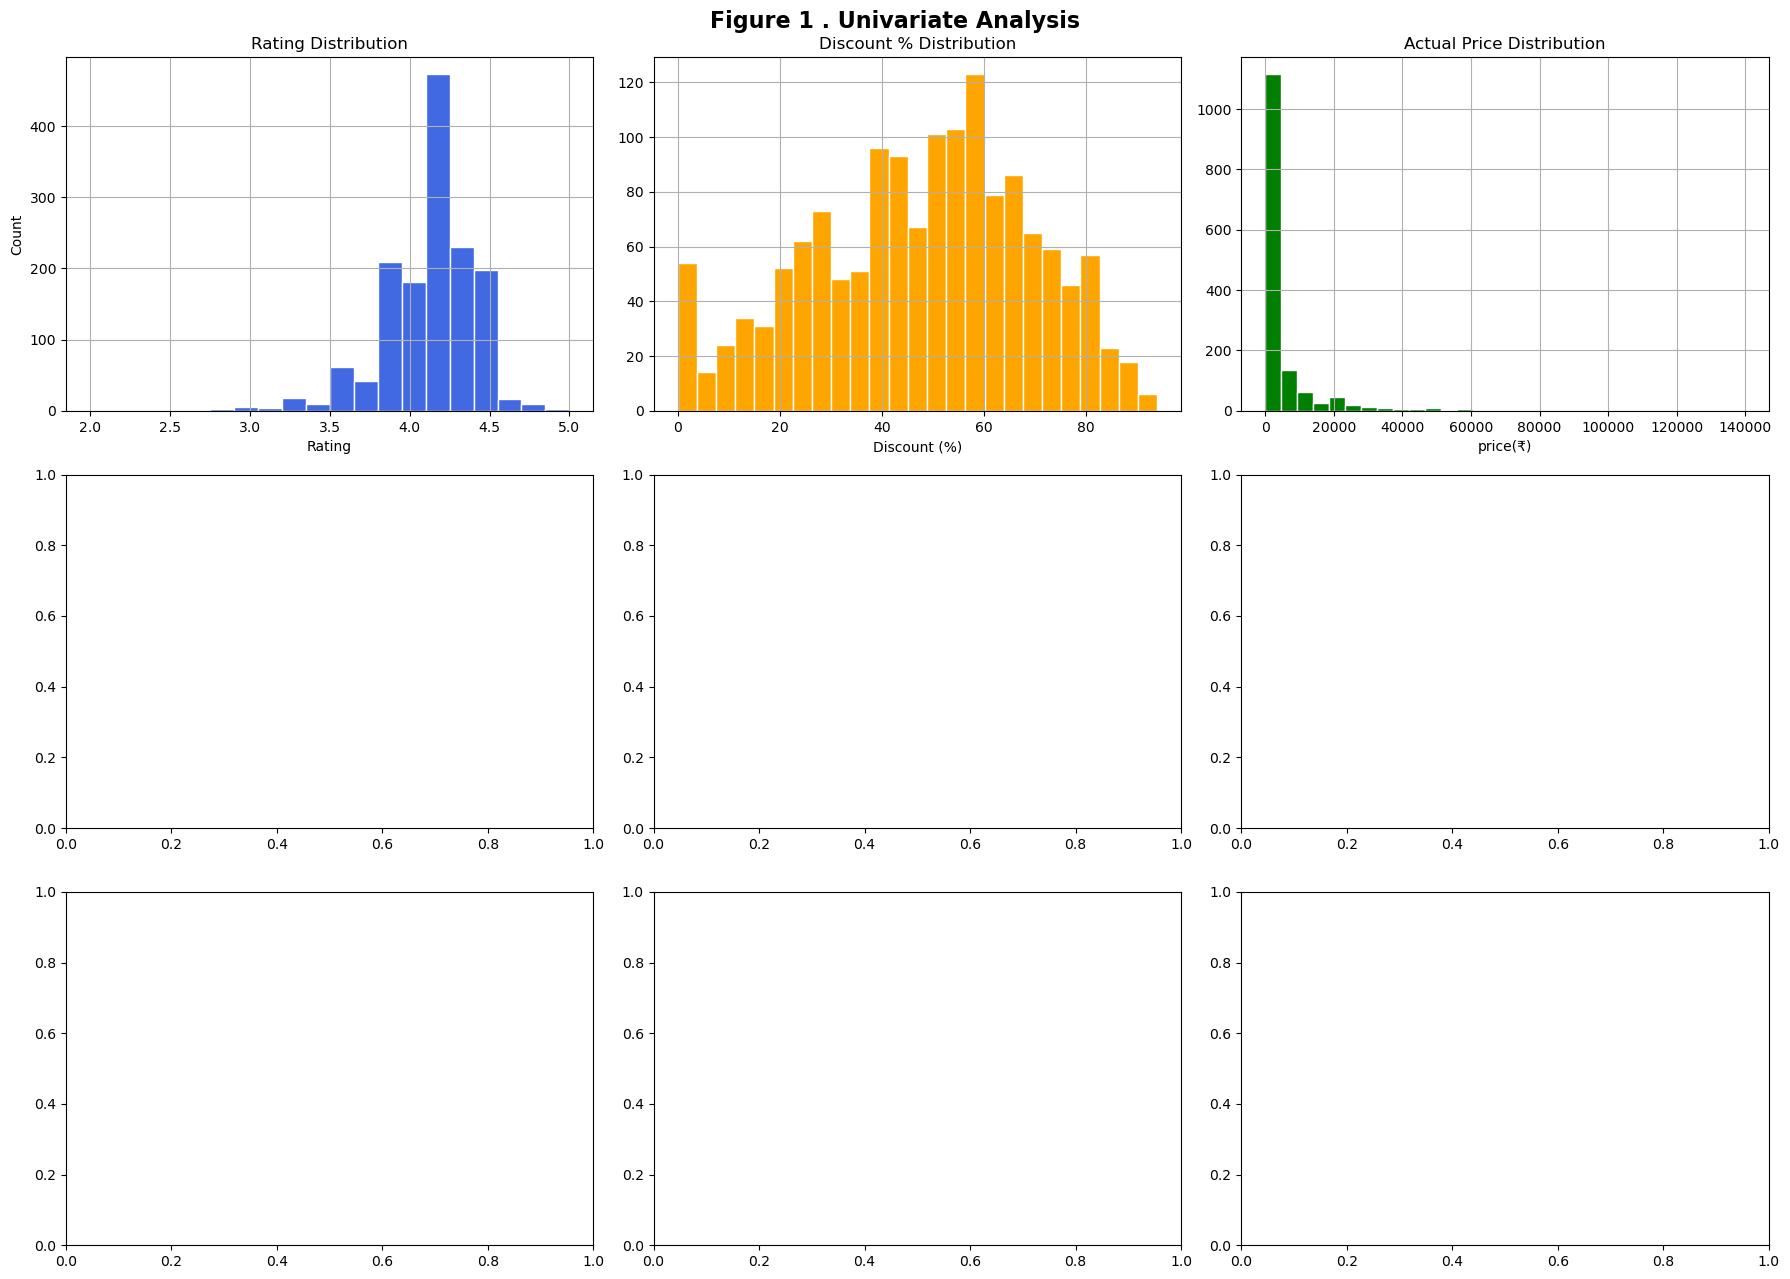

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
df['rating'].hist(ax=axes[0,0], color='royalblue',
                 edgecolor='white', bins=20)
axes[0,0].set_title('Rating Distribution')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Count')
df['discount_percentage'].hist(ax=axes[0,1], color='orange',
                              edgecolor='white', bins=25)
axes[0,1].set_title('Discount % Distribution')
axes[0,1].set_xlabel('Discount (%)')
df['actual_price'].hist(ax=axes[0,2], color='green',
                        edgecolor='white', bins=30)
axes[0,2].set_title('Actual Price Distribution')
axes[0,2].set_xlabel('price(₹)')

fig.suptitle('Figure 1 . Univariate Analysis', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


 Figure 2 -  Bivariate charts (3x3 subplot) 

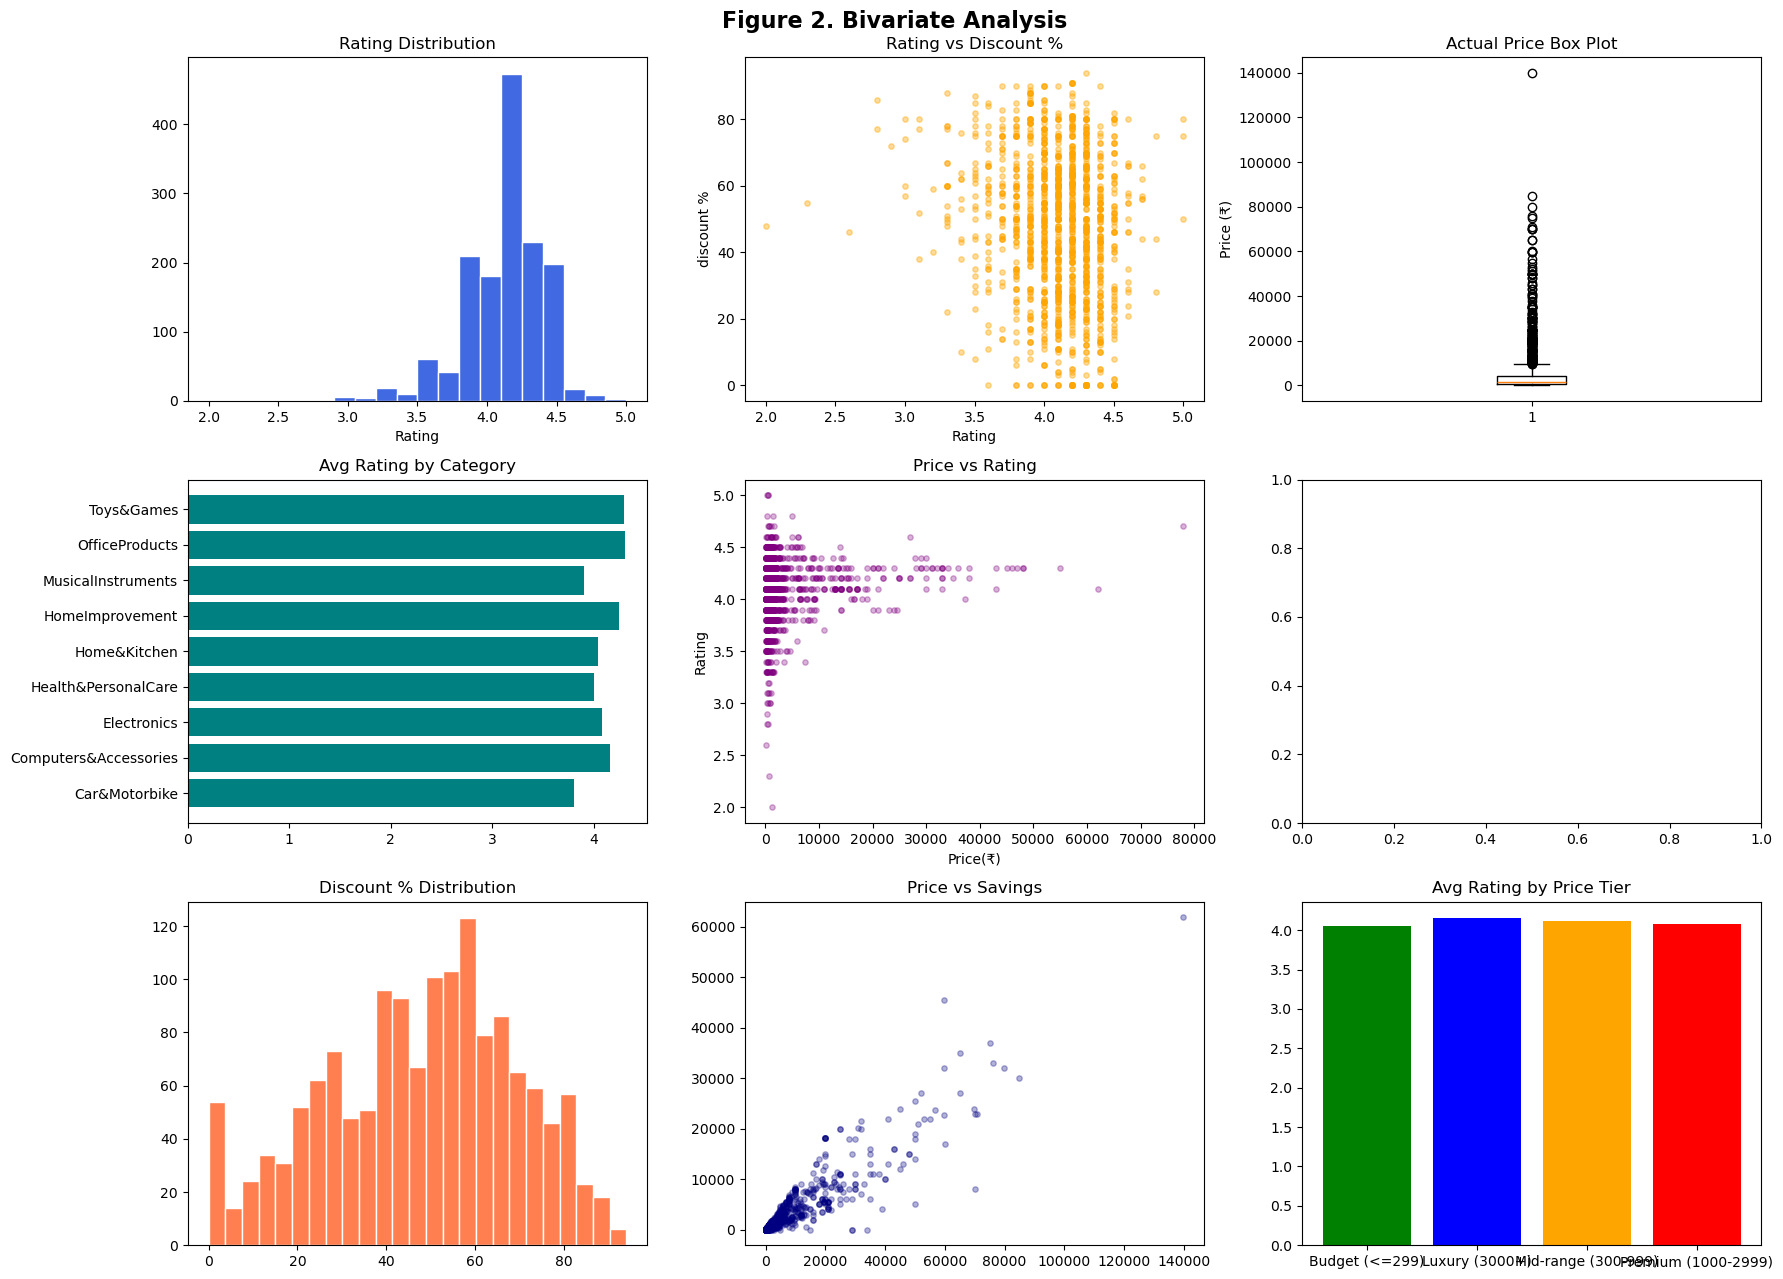

In [11]:
fig2, axes = plt.subplots(3, 3, figsize=(18, 13))
axes[0,0].hist(df['rating'], bins=20,
    color='royalblue', edgecolor='white')
axes[0,0].set_title('Rating Distribution')
axes[0,0].set_xlabel('Rating')
axes[0,1].scatter(df['rating'],
     df['discount_percentage'],
     alpha=0.4, color='orange', s=15)             
axes[0,1].set_title('Rating vs Discount %')
axes[0,1].set_xlabel('Rating')
axes[0,1].set_ylabel('discount %')
axes[0,2].boxplot(df['actual_price'])
axes[0,2].set_title('Actual Price Box Plot')
axes[0,2].set_ylabel('Price (₹)')
cat_avg =df.groupby('main_category')['rating'].mean()
axes[1,0].barh(cat_avg.index, cat_avg.values,
              color='teal')
axes[1,0].set_title('Avg Rating by Category')
axes[1,1].scatter(df['discounted_price'],
     df['rating'], alpha=0.3, color='purple', s=15)
axes[1,1].set_title('Price vs Rating')
axes[1,1].set_xlabel('Price(₹)')
axes[1,1].set_ylabel('Rating')
axes[2,0].hist(df['discount_percentage'],
    bins=25, color='coral', edgecolor='white')
axes[2,0].set_title('Discount % Distribution')
axes[2,1].scatter(df['actual_price'],
     df['savings_amount'],
     alpha=0.3, color='navy', s=15)
axes[2,1].set_title('Price vs Savings')
price_avg =df.groupby('price_category',
     observed=True)['rating'].mean()
axes[2,2].bar(price_avg.index, price_avg.values,
     color=['green','blue','orange','red'])
axes[2,2].set_title('Avg Rating by Price Tier')
fig2.suptitle('Figure 2. Bivariate Analysis',
     fontsize=16, fontweight='bold')         
plt.tight_layout()
plt.savefig('fig2.png', dpi=150)
plt.show()


Figure 3 - Multivariate, Pivot Heatmaps & Correlaation

In [13]:
df = pd.read_csv('amazon_cleaned.csv')

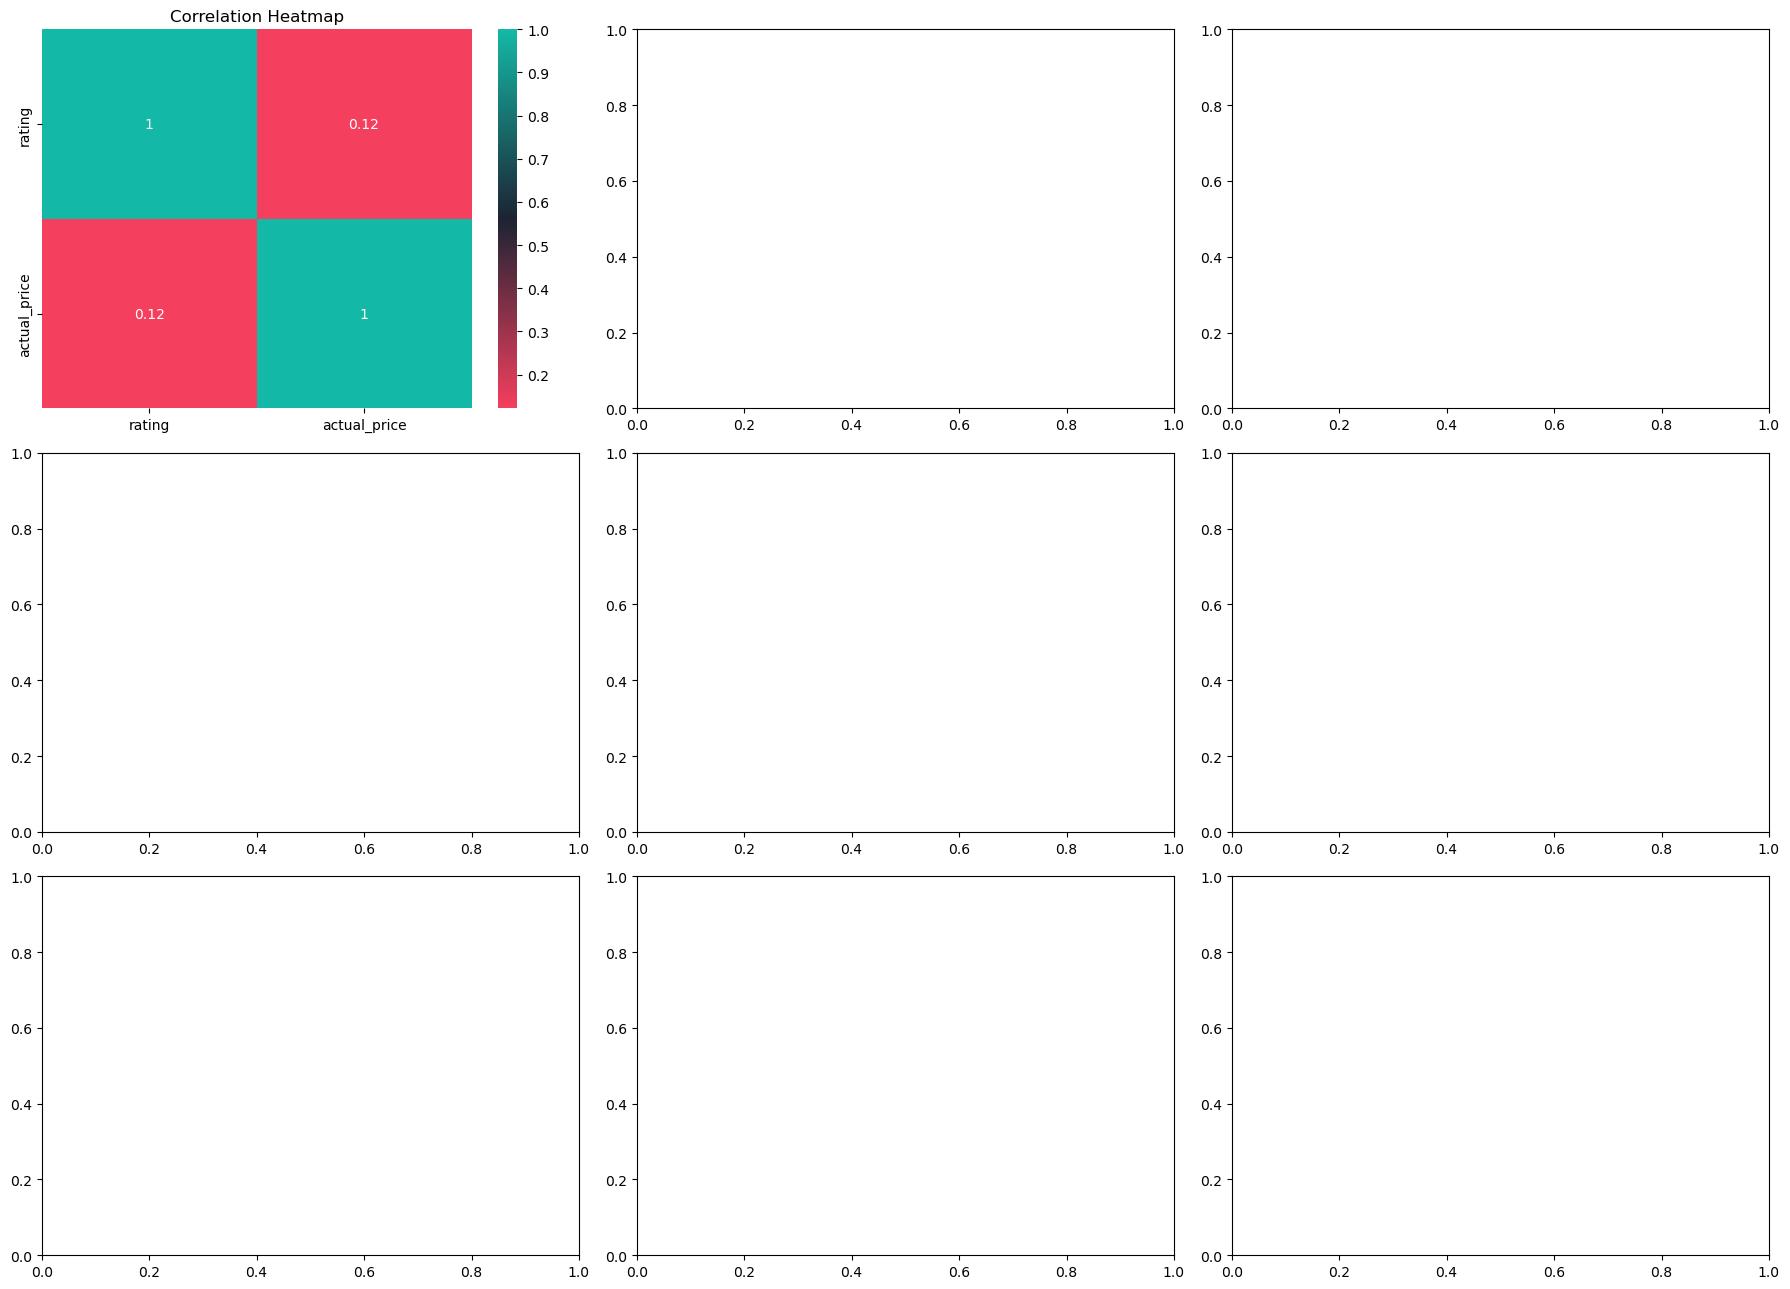

In [15]:
from matplotlib.colors import LinearSegmentedColormap
fig3, axes = plt.subplots(3, 3, figsize=(18, 13))
corr =df[['rating','actual_price']].corr()
sns.heatmap(corr, ax=axes[0, 0],cmap=cmap_div,annot=True)
axes[0, 0].set_title('Correlation Heatmap')
plt.tight_layout()
fig3.savefig('fig3.png', dpi=150)
plt.show()


In [21]:
df['price_tier'] = pd.cut(
    df['actual_price'],
    bins=[0,300,1000,3000,float('inf')],
    labels=['Budget','Mid-range','Premium','Luxury'])
print(df['price_tier'].value_counts())

price_tier
Mid-range    465
Luxury       465
Premium      459
Budget        76
Name: count, dtype: int64


In [22]:
pivot1 = df.pivot_table(
    index='category',
    columns='price_tier',
    values='rating',
    aggfunc='mean'
)
pivot2= df.pivot_table(
    index='rating_band',
    columns='price_tier',
    values='rating',
    aggfunc='mean'
)    
sns.heatmap(pivot1, ax=axes[1,0], cmap=cmap_div, annot=True, fmt='.2f')
sns.heatmap(pivot2, ax=axes[1,1], cmap=cmap_div, annot=True, fmt='.2f')


C:\Users\neena\AppData\Local\Temp\ipykernel_5056\1776334216.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot1 = df.pivot_table(
C:\Users\neena\AppData\Local\Temp\ipykernel_5056\1776334216.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot2= df.pivot_table(


<Axes: xlabel='price_tier', ylabel='rating_band'>